#📌 Extracción

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar dataset
url = "https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/main/TelecomX_Data.json"

df = pd.read_json(url)

# Ver primeras filas
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


#🔧 Transformación

In [ ]:
from pandas import json_normalize

# Aplanar estructura del JSON
df_final = json_normalize(df.to_dict(orient="records"))

# Ver columnas
df_final.columns

Index(['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total'],
      dtype='object')

In [ ]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [ ]:
df_final["account.Charges.Total"] = pd.to_numeric(df_final["account.Charges.Total"], errors="coerce")

#📊 Carga y análisis

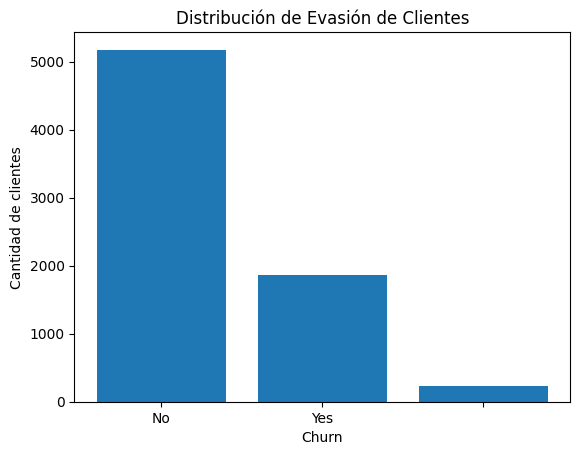

In [ ]:
churn = df_final["Churn"].value_counts()

plt.figure()
plt.bar(churn.index, churn.values)

plt.title("Distribución de Evasión de Clientes")
plt.xlabel("Churn")
plt.ylabel("Cantidad de clientes")

plt.show()

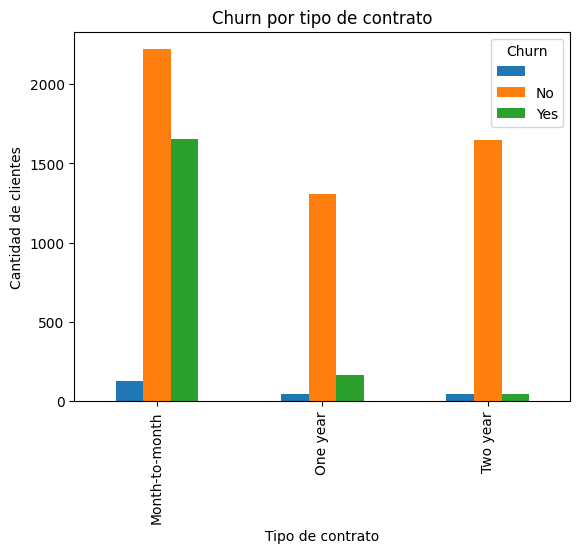

In [ ]:
contrato = df_final.groupby("account.Contract")["Churn"].value_counts().unstack()

contrato.plot(kind="bar")

plt.title("Churn por tipo de contrato")
plt.xlabel("Tipo de contrato")
plt.ylabel("Cantidad de clientes")

plt.show()

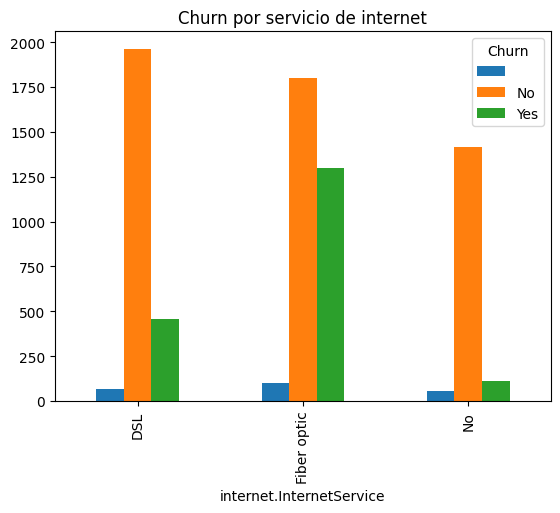

In [ ]:
internet = df_final.groupby("internet.InternetService")["Churn"].value_counts().unstack()

internet.plot(kind="bar")

plt.title("Churn por servicio de internet")

plt.show()

#📄Informe final

In [ ]:
1. Los clientes con contratos mensuales presentan mayor tasa de abandono.
2. Los clientes con servicio de internet Fiber Optic presentan mayor churn.
3. Los clientes con mayor antigüedad tienen menor probabilidad de cancelar el servicio.
4. Los métodos de pago electrónicos muestran mayor tasa de cancelación.

Recomendaciones:

- Incentivar contratos anuales o de dos años.
- Revisar la calidad del servicio Fiber Optic.
- Implementar programas de fidelización para clientes nuevos.

SyntaxError: invalid syntax (1319720433.py, line 1)

In [ ]:
from pandas import json_normalize

df_final = json_normalize(df.to_dict(orient="records"))

In [ ]:
df_final.to_csv("TelecomX_tratado.csv", index=False)

In [ ]:
df_final = df_final.dropna()

In [ ]:
df_final.to_csv("TelecomX_tratado.csv", index=False)

In [ ]:
from google.colab import files
files.download("TelecomX_tratado.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df_final.to_csv("/content/drive/MyDrive/TelecomX_tratado.csv", index=False)

In [ ]:
df_final = df_final.dropna()

df_final.to_csv("TelecomX_tratado.csv", index=False)

# TELECOM 2

In [ ]:
df.columns

Index(['customerID', 'Churn', 'customer', 'phone', 'internet', 'account'], dtype='object')

In [ ]:
for col in df.columns:
    print(col)

customerID
Churn
customer
phone
internet
account


In [ ]:
import pandas as pd
from pandas import json_normalize

# expandir las columnas tipo diccionario
df = pd.concat([
    df.drop(['customer','phone','internet','account'], axis=1),
    json_normalize(df['customer']),
    json_normalize(df['phone']),
    json_normalize(df['internet']),
    json_normalize(df['account'])
], axis=1)

In [ ]:
for col in df.columns:
    print(col)

customerID
Churn
gender
SeniorCitizen
Partner
Dependents
tenure
PhoneService
MultipleLines
InternetService
OnlineSecurity
OnlineBackup
DeviceProtection
TechSupport
StreamingTV
StreamingMovies
Contract
PaperlessBilling
PaymentMethod
Charges.Monthly
Charges.Total


In [ ]:
df["Charges.Total"] = pd.to_numeric(df["Charges.Total"], errors="coerce")

df = df.dropna()

df["Churn"] = df["Churn"].map({"Yes":1, "No":0})

df["DailyCharges"] = df["Charges.Monthly"] / 30

Verificación de la Proporción de Cancelación (Churn) - NO = 0  / SI = 1

In [ ]:
df["Churn"].value_counts()

,count
Churn,
0.0,5163
1.0,1869


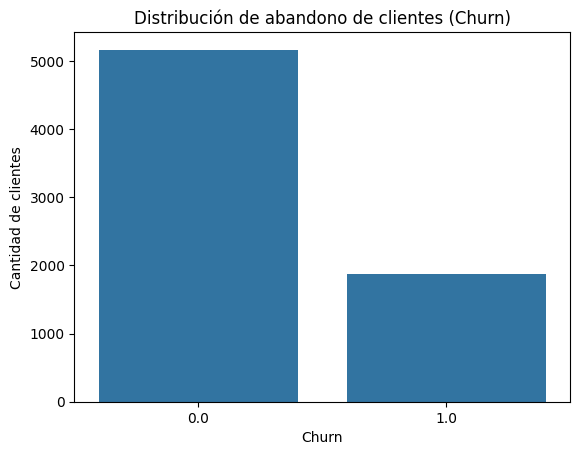

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Churn", data=df)

plt.title("Distribución de abandono de clientes (Churn)")
plt.xlabel("Churn")
plt.ylabel("Cantidad de clientes")

plt.show()

In [ ]:
numeric_cols = ["tenure","Charges.Monthly","Charges.Total"]

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

In [ ]:
df[numeric_cols].describe()

,tenure,Charges.Monthly,Charges.Total
count,7.256000e+03,7.256000e+03,7.256000e+03
mean,9.302861e-17,-9.792485e-18,-5.875491e-18
std,1.000069e+00,1.000069e+00,1.000069e+00
min,-1.278509e+00,-1.543817e+00,-9.970718e-01
25%,-9.527275e-01,-9.728373e-01,-8.289304e-01
50%,-1.382751e-01,1.840605e-01,-3.921725e-01
75%,9.205131e-01,8.347118e-01,6.632935e-01
max,1.612798e+00,1.792431e+00,2.823113e+00


Correlación y Selección de Variables

In [ ]:
corr = df[["tenure","Charges.Monthly","Charges.Total","Churn"]].corr()

corr

,tenure,Charges.Monthly,Charges.Total,Churn
tenure,1.000000,0.246981,0.825118,-0.354049
Charges.Monthly,0.246981,1.000000,0.652109,0.192858
Charges.Total,0.825118,0.652109,1.000000,-0.199484
Churn,-0.354049,0.192858,-0.199484,1.000000


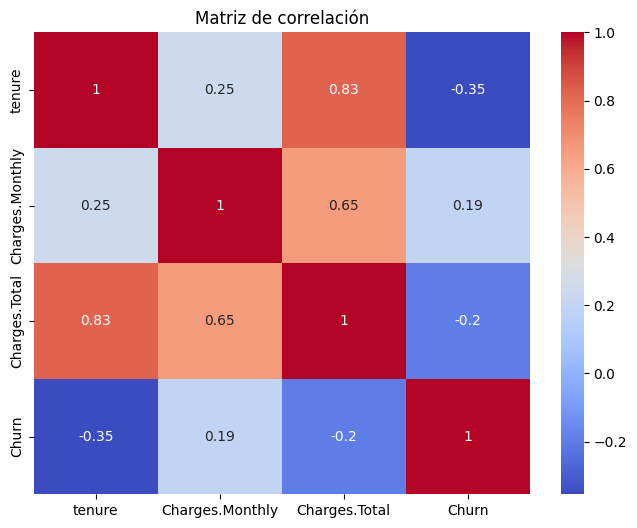

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Matriz de correlación")

plt.show()

ANALISIS DIRIGIDO

In [ ]:
corr["Churn"].sort_values(ascending=False)

,Churn
Churn,1.000000
Charges.Monthly,0.192858
Charges.Total,-0.199484
tenure,-0.354049


MODELADO PREDICTIVO

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [ ]:
import pandas as pd

customer_df = pd.json_normalize(df["customer"])
phone_df = pd.json_normalize(df["phone"])
internet_df = pd.json_normalize(df["internet"])
account_df = pd.json_normalize(df["account"])

In [ ]:
df_final = pd.concat(
    [customer_df, phone_df, internet_df, account_df, df["Churn"]],
    axis=1
)

In [ ]:
df_final = pd.get_dummies(df_final, drop_first=True)

In [ ]:
X = df_final.drop("Churn_Yes", axis=1)
y = df_final["Churn_Yes"]

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

separacion de datos

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

CREACION DE MODELOS

Regregion logistica

In [ ]:
from sklearn.linear_model import LogisticRegression

modelo = LogisticRegression()

modelo.fit(X_train, y_train)

LogisticRegression()

Random forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

rf.fit(X_train, y_train)

RandomForestClassifier()

evaluacion de modelos

In [ ]:
from sklearn.metrics import accuracy_score

pred = rf.predict(X_test)

accuracy_score(y_test, pred)

0.9564419990829894

Matriz de confusion

In [ ]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, pred)

array([[1613,   36],
       [  59,  473]])

interpretacion  y conclusiones

In [ ]:
import pandas as pd

importancias = pd.Series(rf.feature_importances_, index=X.columns)

importancias.sort_values(ascending=False).head(10)

,0
Churn_No,0.370946
tenure,0.071928
Charges.Monthly,0.052693
PaymentMethod_Electronic check,0.021027
Contract_Two year,0.019201
InternetService_Fiber optic,0.017847
Contract_One year,0.014913
TechSupport_Yes,0.014750
OnlineSecurity_Yes,0.014665
PaperlessBilling_Yes,0.012431


Análisis de la Importancia de las Variables

conclusion

Ejemplo:

Principales factores que influyen en la cancelación:

Contratos mensuales

Cargos mensuales altos

Baja antigüedad del cliente

Servicio de fibra óptica

Recomendaciones:

Incentivar contratos de largo plazo

Programas de fidelización para clientes nuevos

Revisar la experiencia del servicio de fibra óptica